In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness

# custom noisy backend (or an attempt at one, at least)
class NoisyBackend(GenericBackendV2):
    def __init__(
        self,
        num_qubits: int,
        basis_gates: list[str] | None = None,
        coupling_map: list[list[int]] = None,
        p1: float = 0,
        p2: float = 0,
    ):
        self.p = (p1,p2)
        super().__init__(
            num_qubits,
            basis_gates,
            coupling_map=coupling_map,
            noise_info = (p1>0 or p2 >0)
            )
    def _get_noise_defaults(self, name: str, num_qubits: int) -> tuple:
        if name in ['delay', 'reset']:
            return (self.p[0],self.p[0])
        else:
            if num_qubits == 1:
                return (0,0,self.p[0],self.p[0])
            else:
                return (0,0,self.p[1],self.p[1])


We'll look at Quantum Awesomeness on either a real 127 qubit device, or a small emulated backend.

In [2]:
real_device = False

if real_device:
    from qiskit_ibm_provider import IBMProvider
    provider = IBMProvider(instance="ibm-q/open/main")
    backend = provider.get_backend('ibm_sherbrooke')
else:
    p = 0.0015
    backend = NoisyBackend(
    num_qubits=8,
    basis_gates = ["id", "h", "x", "y", "z", "rx", "cx"],
    p1=p/10,
    p2=p,
    )

First we set up the experiment. 

Some notes on parameters:
* `range(backend.num_qubits)`: We use the whole device.
* `two_qubit_gate_density=0.25`: Having around half of all qubits involved in an entangling gate seems like a good fraction, and this makes that happen.
* `initial_entangling_angle=np.pi/2`: Default angle is `np.pi/2`, which creates maximally entangled pairs. We'll use `np.pi/2` so we can more easily see the gates when looking at the circuits.
* `num_samples=20`: Number of different sets of random Clifford circuits.

In [3]:
# number of shots per circuit
shots = 10000

# lengths of different mirror circuits to run
lengths = [2]+[4,10,20,50,100]

# set up the experiment object
exp = MirrorQA(
    range(backend.num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=20,
    initial_entangling_angle=np.pi/4,
    )
exp.set_run_options(
    shots=shots
)


Now we run it!

In [4]:
#run
rb_data = exp.run()
print(rb_data.job_ids)

True
hola
['0161f9ca-1ea4-4e7d-b1d3-6005a93e3c54']


To see what circuits were run, don't use `exp.circuits()` because that will set up a new bunch of circuits. Instead use `exp._static_trans_circuits`, which stores the transpiled circuits that were run.

There are two differences between MQA circuits and MRB circuits:
* MQA places the new layers of the sequence at the beginning and end, whereas MRB places them in the middle.
* MQA inserts `rx` gates on the control qubit of any qubit involved in a CX in the first layer. Leading to entanglement for all pairs involved in a CX in the first layer.

To see what pairs were used for the CX gates in the first layer of each circuit, use `exp._pairs`.

Below are the first two lengths of circuit for the first sequence of random Cliffords. The `Rx(π/4)` gates here are those inserted to create the entangled pairs.

In [5]:
print('Pairs:', exp._pairs[0])
exp._static_trans_circuits[0].draw(fold=-1)

Pairs: [(7, 4), (3, 2)]


global phase: π/2
              ░ ┌───┐┌─────────┐    ┌───┐    ┌───┐ ░ ┌───┐ ░    ┌───┐   ┌─────────┐┌───┐      ░ ┌───┐ ░  ░ ┌─┐                     
   q_0: ──────░─┤ H ├┤ Rx(π/2) ├────┤ H ├────┤ Z ├─░─┤ Z ├─░────┤ H ├───┤ Rx(π/2) ├┤ H ├──────░─┤ X ├─░──░─┤M├─────────────────────
        ┌───┐ ░ ├───┤├─────────┴┐   ├───┤    └───┘ ░ ├───┤ ░ ┌──┴───┴──┐└──┬───┬──┘├───┤      ░ ├───┤ ░  ░ └╥┘┌─┐                  
   q_1: ┤ Z ├─░─┤ H ├┤ Rx(-π/2) ├───┤ Y ├──────────░─┤ X ├─░─┤ Rx(π/2) ├───┤ H ├───┤ X ├──────░─┤ Y ├─░──░──╫─┤M├──────────────────
        ├───┤ ░ ├───┤└──────────┘   └───┘          ░ └───┘ ░ └──┬───┬──┘   └───┘   └───┘      ░ ├───┤ ░  ░  ║ └╥┘┌─┐               
   q_2: ┤ X ├─░─┤ X ├──────────────────────────────░───────░────┤ X ├─────────────────────────░─┤ Y ├─░──░──╫──╫─┤M├───────────────
        ├───┤ ░ └─┬─┘┌─────────┐                   ░ ┌───┐ ░    └─┬─┘                         ░ └───┘ ░  ░  ║  ║ └╥┘┌─┐            
   q_3: ┤ X ├─░───■──┤ Rx(π/4) ├───────────────────░─┤ Z ├─░──────■───────────────────────────░───────░──░──╫──╫──╫─┤M├────────────
        └───┘ ░ ┌───┐└─────────┘                   ░ └───┘ ░               ┌───┐              ░ ┌───┐ ░  ░  ║  ║  ║ └╥┘┌─┐         
   q_4: ──────░─┤ X ├──────────────────────────────░───────░───────────────┤ X ├──────────────░─┤ Y ├─░──░──╫──╫──╫──╫─┤M├─────────
        ┌───┐ ░ └─┬─┘   ┌───┐    ┌──────────┐┌───┐ ░       ░ ┌─────────┐   └─┬─┘   ┌───┐┌───┐ ░ ├───┤ ░  ░  ║  ║  ║  ║ └╥┘┌─┐      
   q_5: ┤ X ├─░───┼─────┤ H ├────┤ Rx(-π/2) ├┤ Z ├─░───────░─┤ Rx(π/2) ├─────┼─────┤ H ├┤ Y ├─░─┤ Z ├─░──░──╫──╫──╫──╫──╫─┤M├──────
        ├───┤ ░   │     ├───┤    ├──────────┤├───┤ ░       ░ ├─────────┤     │     ├───┤├───┤ ░ ├───┤ ░  ░  ║  ║  ║  ║  ║ └╥┘┌─┐   
   q_6: ┤ X ├─░───┼─────┤ H ├────┤ Rx(-π/2) ├┤ Z ├─░───────░─┤ Rx(π/2) ├─────┼─────┤ H ├┤ Y ├─░─┤ X ├─░──░──╫──╫──╫──╫──╫──╫─┤M├───
        ├───┤ ░   │  ┌──┴───┴──┐ └──────────┘└───┘ ░       ░ └─────────┘     │     └───┘└───┘ ░ └───┘ ░  ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐
   q_7: ┤ Y ├─░───■──┤ Rx(π/4) ├───────────────────░───────░─────────────────■────────────────░───────░──░──╫──╫──╫──╫──╫──╫──╫─┤M├
        └───┘ ░      └─────────┘                   ░       ░                                  ░       ░  ░  ║  ║  ║  ║  ║  ║  ║ └╥┘
meas: 8/════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩══╩══╩═
                                                                                                            0  1  2  3  4  5  6  7

In [6]:
print('Pairs:', exp._pairs[1])
exp._static_trans_circuits[1].draw(fold=-1)

Pairs: [(2, 0)]


global phase: 3π/2
              ░    ┌───┐                                 ░       ░ ┌───┐┌─────────┐    ┌───┐    ┌───┐ ░ ┌───┐ ░    ┌───┐   ┌─────────┐┌───┐      ░ ┌───┐ ░               ┌───┐               ░ ┌───┐ ░  ░ ┌─┐                     
   q_0: ──────░────┤ X ├─────────────────────────────────░───────░─┤ H ├┤ Rx(π/2) ├────┤ H ├────┤ Z ├─░─┤ Y ├─░────┤ H ├───┤ Rx(π/2) ├┤ H ├──────░─┤ Z ├─░───────────────┤ X ├───────────────░─┤ X ├─░──░─┤M├─────────────────────
        ┌───┐ ░    └─┬─┘      ┌───┐    ┌──────────┐┌───┐ ░ ┌───┐ ░ ├───┤├─────────┴┐   ├───┤    └───┘ ░ ├───┤ ░ ┌──┴───┴──┐└──┬───┬──┘├───┤      ░ ├───┤ ░ ┌─────────┐   └─┬─┘    ┌───┐┌───┐ ░ ├───┤ ░  ░ └╥┘┌─┐                  
   q_1: ┤ Z ├─░──────┼────────┤ H ├────┤ Rx(-π/2) ├┤ X ├─░─┤ Y ├─░─┤ H ├┤ Rx(-π/2) ├───┤ Y ├──────────░─┤ X ├─░─┤ Rx(π/2) ├───┤ H ├───┤ X ├──────░─┤ X ├─░─┤ Rx(π/2) ├─────┼──────┤ H ├┤ Z ├─░─┤ Y ├─░──░──╫─┤M├──────────────────
        ├───┤ ░      │     ┌──┴───┴──┐ └──────────┘└───┘ ░ ├───┤ ░ ├───┤└──────────┘   └───┘          ░ └───┘ ░ └──┬───┬──┘   └───┘   └───┘      ░ └───┘ ░ └─────────┘     │      └───┘└───┘ ░ ├───┤ ░  ░  ║ └╥┘┌─┐               
   q_2: ┤ X ├─░──────■─────┤ Rx(π/4) ├───────────────────░─┤ X ├─░─┤ X ├──────────────────────────────░───────░────┤ X ├─────────────────────────░───────░─────────────────■─────────────────░─┤ Y ├─░──░──╫──╫─┤M├───────────────
        ├───┤ ░    ┌───┐   ├─────────┤    ┌───┐    ┌───┐ ░ └───┘ ░ └─┬─┘                              ░ ┌───┐ ░    └─┬─┘                         ░ ┌───┐ ░    ┌───┐   ┌─────────┐ ┌───┐      ░ └───┘ ░  ░  ║  ║ └╥┘┌─┐            
   q_3: ┤ X ├─░────┤ H ├───┤ Rx(π/2) ├────┤ H ├────┤ Z ├─░───────░───■────────────────────────────────░─┤ Z ├─░──────■───────────────────────────░─┤ Z ├─░────┤ H ├───┤ Rx(π/2) ├─┤ H ├──────░───────░──░──╫──╫──╫─┤M├────────────
        └───┘ ░    ├───┤   ├─────────┴┐   ├───┤    └───┘ ░       ░ ┌───┐                              ░ ├───┤ ░               ┌───┐              ░ └───┘ ░ ┌──┴───┴──┐└──┬───┬──┘ ├───┤      ░ ┌───┐ ░  ░  ║  ║  ║ └╥┘┌─┐         
   q_4: ──────░────┤ H ├───┤ Rx(-π/2) ├───┤ Y ├──────────░───────░─┤ X ├──────────────────────────────░─┤ X ├─░───────────────┤ X ├──────────────░───────░─┤ Rx(π/2) ├───┤ H ├────┤ X ├──────░─┤ Y ├─░──░──╫──╫──╫──╫─┤M├─────────
        ┌───┐ ░    ├───┤   ├─────────┬┘   ├───┤    ┌───┐ ░ ┌───┐ ░ └─┬─┘   ┌───┐    ┌──────────┐┌───┐ ░ └───┘ ░ ┌─────────┐   └─┬─┘   ┌───┐┌───┐ ░       ░ └──┬───┬──┘┌──┴───┴──┐ ├───┤      ░ ├───┤ ░  ░  ║  ║  ║  ║ └╥┘┌─┐      
   q_5: ┤ X ├─░────┤ H ├───┤ Rx(π/2) ├────┤ H ├────┤ Z ├─░─┤ X ├─░───┼─────┤ H ├────┤ Rx(-π/2) ├┤ Z ├─░───────░─┤ Rx(π/2) ├─────┼─────┤ H ├┤ Y ├─░───────░────┤ H ├───┤ Rx(π/2) ├─┤ H ├──────░─┤ Z ├─░──░──╫──╫──╫──╫──╫─┤M├──────
        ├───┤ ░ ┌──┴───┴──┐└──┬───┬──┘    ├───┤    └───┘ ░ ├───┤ ░   │     ├───┤    ├──────────┤├───┤ ░ ┌───┐ ░ ├─────────┤     │     ├───┤├───┤ ░       ░    ├───┤   ├─────────┴┐├───┤      ░ ├───┤ ░  ░  ║  ║  ║  ║  ║ └╥┘┌─┐   
   q_6: ┤ X ├─░─┤ Rx(π/2) ├───┤ H ├───────┤ X ├──────────░─┤ X ├─░───┼─────┤ H ├────┤ Rx(-π/2) ├┤ Z ├─░─┤ Z ├─░─┤ Rx(π/2) ├─────┼─────┤ H ├┤ Y ├─░───────░────┤ H ├───┤ Rx(-π/2) ├┤ Y ├──────░─┤ X ├─░──░──╫──╫──╫──╫──╫──╫─┤M├───
        ├───┤ ░ ├─────────┤   ├───┤       ├───┤          ░ └───┘ ░   │     └───┘    └──────────┘└───┘ ░ ├───┤ ░ └─────────┘     │     └───┘└───┘ ░       ░    ├───┤   ├──────────┤├───┤      ░ └───┘ ░  ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐
   q_7: ┤ Y ├─░─┤ Rx(π/2) ├───┤ H ├───────┤ Z ├──────────░───────░───■────────────────────────────────░─┤ Z ├─░─────────────────■────────────────░───────░────┤ H ├───┤ Rx(-π/2) ├┤ X ├──────░───────░──░──╫──╫──╫──╫──╫──╫──╫─┤M├
        └───┘ ░ └─────────┘   └───┘       └───┘          ░       ░                                    ░ └───┘ ░                                  ░       ░    └───┘   └──────────┘└───┘      ░       ░  ░  ║  ║  ║  ║  ║  ║  ║ └╥┘
meas: 8/══════════════════════════════════════════════════════════════════════════════════════════════════════════════════

Now we can analyze the data according to our desired analysis method.

In [7]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
#exp.analysis.set_options(analyzed_quantity='Mutual Information')
analysis = exp.analysis.run(rb_data)

Then plot the results.

Note: if you get the `'Figure index 0 out of range.'` error, it might be because the analysis is still running in the background. So just try again.

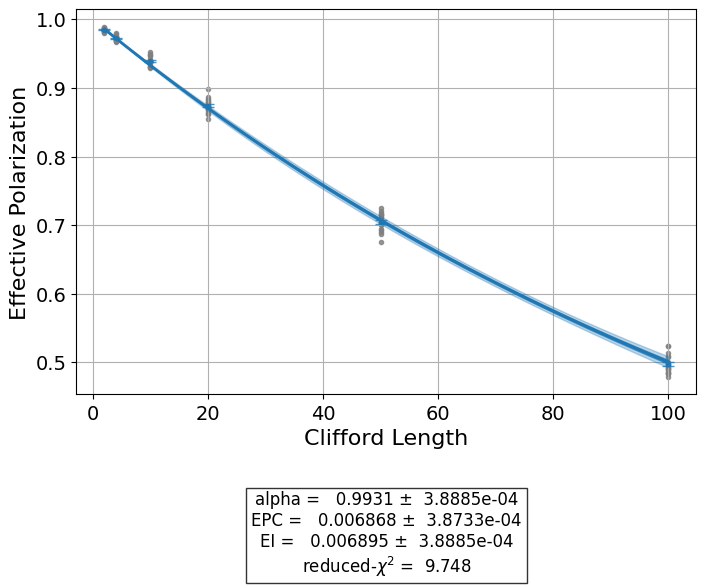

In [9]:
analysis.figure(0)

When we calculate the mutual informations, it is done by the `QuantumAwesomeness` object. We can also use this directly.

In [10]:
qa = QuantumAwesomeness(exp.backend.coupling_map)

It can be used to calculate the MIs for each pair in the coupling map for each circuit that was run.

In [11]:
mi = qa.mutual_info(rb_data.data())

It can also be used to calculate the mean MIs, where separate means are taken for the entangled pairs and the non-entangled pairs.

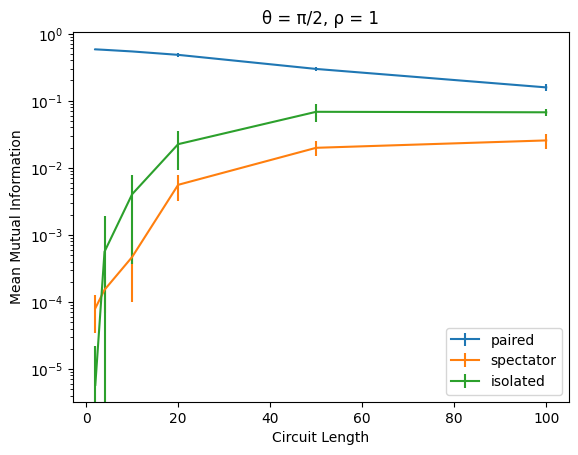

In [ ]:
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(3)]
yerrs = [[],[],[]]

for p, pairtype in enumerate(['paired', 'unpaired', 'singles']):
    for j, m in enumerate(mmi[pairtype]):
        # m can be array-like; avoid ambiguous truth-value by checking element-wise NaNs
        m_arr = np.asarray(m)
        # skip if all entries are NaN
        if np.all(np.isnan(m_arr)):
            continue
        # use the mean of the available values (ignoring NaNs) as the representative scalar
        val = np.nanmean(m_arr)
        ys[p][j % 6].append(val)

    for j in range(6):
        if len(ys[p][j]) == 0:
            # no data for this bin -> keep a placeholder (nan) and zero error
            yerrs[p].append(0.0)
            ys[p][j] = np.nan
        else:
            yerrs[p].append(np.std(ys[p][j]))
            ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='spectator')
plt.errorbar(lengths,ys[2],yerr=yerrs[2],label='isolated')
plt.yscale('log')
plt.legend()
plt.xlabel('Circuit Length')
plt.ylabel('Mean Mutual Information')
plt.title('θ = π/2, ρ = 1')


Pickled results from a run on `'ibm_sherbrooke'`can be found in the following files.

* `exp`: `'pickled_sherbrooke/exp_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `data`: `'pickled_sherbrooke/data_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `data.data()`: `'pickled_sherbrooke/data_data_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`
* `mi`: `'pickled_sherbrooke/mi_c0cc1667-c4da-475d-86c5-f85771ad4ce5.p'`



In [ ]:
# Save paired and its error, unpaired and its error and singles and its error to csv to be able to reproduce plots later
import pandas as pd
data = {
    'lengths': lengths,
    'mmi_paired': ys[0],
    'mmi_paired_err': yerrs[0],
    'mmi_unpaired': ys[1],
    'mmi_unpaired_err': yerrs[1],
    'mmi_singles': ys[2],
    'mmi_singles_err': yerrs[2]
}
df = pd.DataFrame(data)
df.to_csv('mmi_data_null_angle.csv', index=False)